In [1]:
building = 1
time = 24
price = 'Realistic'

battery_capacity = 9.0

# Setup

In [2]:
import torch
import pandas as pd
import numpy as np
import math

import src.data.dataprep as prep
import src.data.featurisation as features

from src.models.lstm import LSTM
from src.models.lstmopt import LSTMOPT
from src.models.lstmopt import CVXLayer

from src.training.training import  Training as Training
from src.training.training_opt import Training as Training_opt

import src.optimization.pv_battery as pvb

import src.tensors.tensorisation as tensor

import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error as mse

def torch_py(torch_tensor):
    return torch_tensor.cpu().detach().numpy().flatten()

def rescale(values, scaler):
    rescaled_values = values * (scaler[1] - scaler[0]) + scaler[0]   
    return rescaled_values

def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

In [3]:
# Import the base data and resample it from 5 minutes to hourly
nl_data = prep.dutch_data('../data/Dutchdata_clean/building_' + str(building) + '.parquet', 'h', price=price)

In [4]:
featurisation = features.Featurisation(nl_data)
nl_data = featurisation.cyclic_features(yearly=False)[0]
nl_data.head()

,load,solar_energy,net_load,offtake,injection,cost,hour_sin,hour_cos
2018-07-01 00:00:00,0.556,0.0,0.556,0.18878,0.030,0.104962,0.000000,1.000000
2018-07-01 01:00:00,0.333,0.0,0.333,0.18178,0.024,0.060533,0.258819,0.965926
2018-07-01 02:00:00,0.347,0.0,0.347,0.17278,0.018,0.059955,0.500000,0.866025
2018-07-01 03:00:00,0.340,0.0,0.340,0.16278,0.010,0.055345,0.707107,0.707107
2018-07-01 04:00:00,0.289,0.0,0.289,0.16478,0.012,0.047621,0.866025,0.500000


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Parameters

In [6]:
# Base parameters
max_charge = battery_capacity/2.7
max_discharge = max_charge
layers = 3
neurons = 200
features = 3
train_test_split = 0.6

past_features = ['solar_energy']
opt_future_features = ['hour_sin','hour_cos','load','offtake','injection']
domain_min = [None, None, None, 0, 0, 0, None]
domain_max = [None, None, None, 1, 1, 1, None]

In [7]:
pvb_system = pvb.PV_battery(nl_data, building, battery_capacity, max_charge, max_discharge, self_consumption=False)

In [27]:
lowest_T = 6

In [28]:
dictionary_list_perfect = pvb_system.execute_optimization(time,lowest_T,'Perfect',neurons,layers,past_features,opt_future_features,domain_min,domain_max,train_test_split=train_test_split)
dictionary_list_naive = pvb_system.execute_optimization(time,lowest_T,'Naive',neurons,layers,past_features,opt_future_features,domain_min,domain_max,train_test_split=train_test_split)
dictionary_list_lstm = pvb_system.execute_optimization(time,lowest_T,'LSTM',neurons,layers,past_features,opt_future_features,domain_min,domain_max,train_test_split=train_test_split)
dictionary_list_cvx = pvb_system.execute_optimization(time,lowest_T,'CVX',neurons,layers,past_features,opt_future_features,domain_min,domain_max,train_test_split=train_test_split)
dictionary_list_lstm_cvx = pvb_system.execute_optimization(time,lowest_T,'LSTM_CVX',neurons,layers,past_features,opt_future_features,domain_min,domain_max,train_test_split=train_test_split)

Setting up optimization for 0:00


C:\Users\jdepoort\Anaconda3\lib\site-packages\cvxpy\reductions\solvers\solving_chain.py:336: FutureWarning: 
    Your problem is being solved with the ECOS solver by default. Starting in 
    CVXPY 1.5.0, Clarabel will be used as the default solver instead. To continue 
    using ECOS, specify the ECOS solver explicitly using the ``solver=cp.ECOS`` 
    argument to the ``problem.solve`` method.
    
  warnings.warn(ECOS_DEPRECATION_MSG, FutureWarning)


Setting up optimization for 1:00
Setting up optimization for 2:00
Setting up optimization for 3:00
Setting up optimization for 4:00
Setting up optimization for 5:00
Setting up optimization for 6:00
Setting up optimization for 7:00
Setting up optimization for 8:00
Setting up optimization for 9:00
Setting up optimization for 10:00
Setting up optimization for 11:00
Setting up optimization for 12:00
Setting up optimization for 13:00
Setting up optimization for 14:00
Setting up optimization for 15:00
Setting up optimization for 16:00
Setting up optimization for 17:00
Setting up optimization for 0:00
Setting up optimization for 1:00
Setting up optimization for 2:00
Setting up optimization for 3:00
Setting up optimization for 4:00
Setting up optimization for 5:00
Setting up optimization for 6:00
Setting up optimization for 7:00
Setting up optimization for 8:00
Setting up optimization for 9:00
Setting up optimization for 10:00
Setting up optimization for 11:00
Setting up optimization for 12:00

In [29]:
hours = range(0,18)

In [30]:
tot_cost_perfect = []
tot_cost_lstm = []
tot_cost_cvx_lstm = []
tot_cost_cvx = []

for hour in hours:
    perfect_cost = (dictionary_list_perfect[hour]['offtake'][:,0] * dictionary_list_perfect[hour]['imp'][:,0]) - (dictionary_list_perfect[hour]['injection'][:,0] * dictionary_list_perfect[hour]['exp'][:,0])
    naive_cost = (dictionary_list_naive[hour]['offtake'][:,0] * dictionary_list_naive[hour]['imp'][:,0]) - (dictionary_list_naive[hour]['injection'][:,0] * dictionary_list_naive[hour]['exp'][:,0])
    lstm_cost = (dictionary_list_lstm[hour]['offtake'][:,0] * dictionary_list_lstm[hour]['imp'][:,0]) - (dictionary_list_lstm[hour]['injection'][:,0] * dictionary_list_lstm[hour]['exp'][:,0])
    cvx_cost = (dictionary_list_cvx[hour]['offtake'][:,0] * dictionary_list_cvx[hour]['imp'][:,0]) - (dictionary_list_cvx[hour]['injection'][:,0] * dictionary_list_cvx[hour]['exp'][:,0])
    lstm_cvx_cost = (dictionary_list_lstm_cvx[hour]['offtake'][:,0] * dictionary_list_lstm_cvx[hour]['imp'][:,0]) - (dictionary_list_lstm_cvx[hour]['injection'][:,0] * dictionary_list_lstm_cvx[hour]['exp'][:,0])
    
    tot_cost_perfect.append(sum(perfect_cost))
    tot_cost_lstm.append(sum(lstm_cost))
    tot_cost_cvx_lstm.append(sum(lstm_cvx_cost))
    tot_cost_cvx.append(sum(cvx_cost))

In [31]:
sum(tot_cost_perfect), sum(tot_cost_lstm), sum(tot_cost_cvx_lstm), sum(tot_cost_cvx)

(26.459643495495044, 96.53832159641654, 78.10706932144697, 106.9235103914576)

In [32]:
pilot_day = 100
model = dictionary_list_lstm_cvx
variable = 'discharge'

final_schedule = np.empty(len(model))

for i in range(len(model)):
    final_schedule[i] = model[i][variable][pilot_day][0]

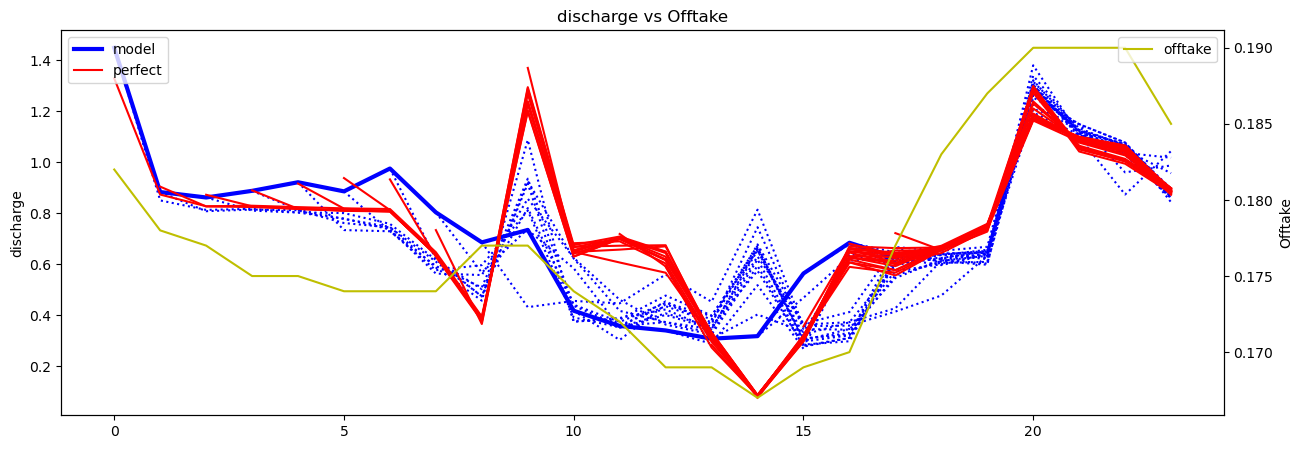

In [33]:
plt.figure(figsize=(15,5))

# Primary axis
ax1 = plt.gca()

# Plot energy data on ax1
ax1.plot(model[0][variable][pilot_day], linestyle=':', color='b')
for i in range(1, len(model)):
    ax1.plot(np.pad(model[i][variable][pilot_day], (i, 0), mode='constant', constant_values=np.nan), linestyle=':', color='b')

ax1.plot(final_schedule, color='b', linewidth=3, label='model')

ax1.plot(dictionary_list_perfect[0][variable][pilot_day], color='r', label='perfect')
for i in range(1, len(dictionary_list_perfect)):
    ax1.plot(np.pad(dictionary_list_perfect[i][variable][pilot_day], (i, 0), mode='constant', constant_values=np.nan), color='r')

ax1.set_ylabel(variable)
ax1.legend(loc='upper left')

# Secondary y-axis
ax2 = ax1.twinx()

# Plot offtake on ax2
ax2.plot(model[0]['offtake'][pilot_day], color='y', label='offtake')
ax2.set_ylabel('Offtake')

# Optional: add second legend
ax2.legend(loc='upper right')

plt.title(variable + " vs Offtake")
plt.show()

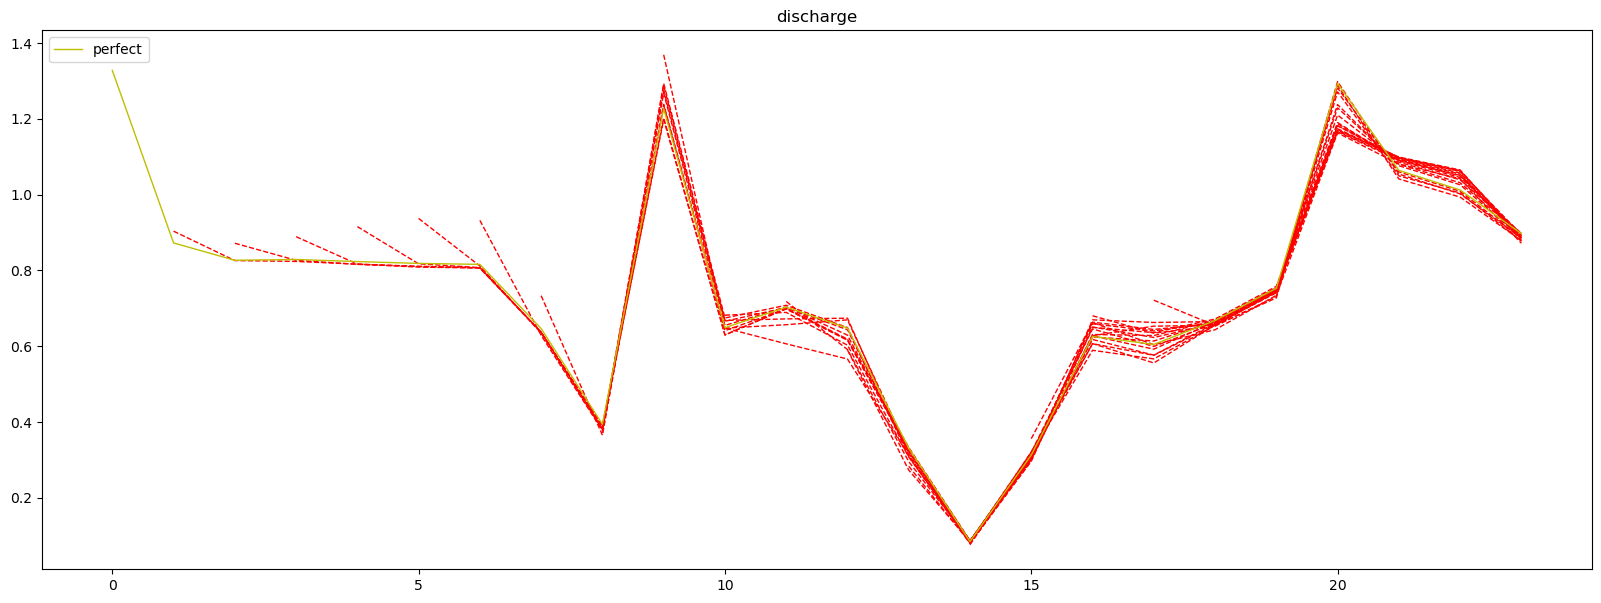

In [53]:
plt.figure(figsize=(20,7))


for i in range(1, len(dictionary_list_perfect)):
    plt.plot(np.pad(dictionary_list_perfect[i][variable][pilot_day], (i, 0), mode='constant', constant_values=np.nan), color='r', linestyle='--', linewidth=1)

plt.plot(dictionary_list_perfect[0][variable][pilot_day], color='y', label='perfect', linewidth=1)

plt.legend(loc='upper left')

plt.title(variable)
plt.show()

In [35]:
import copy

In [88]:
T = time
min_T = lowest_T
model = "Perfect"
past_features = past_features
future_features = opt_future_features

# These values get updated each loop
lags = 24  # The number of lags for this first timeslot: the 24 previous hours
forecast_gap = 0  # The gap after every forecast which is 0 when we need to forecast 24 hours
dictionary_list = []

local_domain_min = copy.deepcopy(domain_min)
local_domain_max = copy.deepcopy(domain_max)

In [89]:
pvb_dictionary = {'imp': [],
                  'exp': [],
                  'energy': [],
                  'charge': [],
                  'discharge': [],
                  'pv': [],
                  'offtake': [],
                  'injection': []}

X_test_list = []

print('Setting up optimization for ' + str(forecast_gap) + ':00')

# Get the optimization problem for the current problem
problem, variables, parameters = pvb_system.create_optimization_problem(T)
# Get what actually happens based on the (dis)charging scheme to obtain the initial battery values
problem_post, variables_post, parameters_post = pvb_system.create_post_forecast_optimization_problem(T)

# Tensors for training an E2E network
local_domain_min[-1] = 0
local_domain_max[-1] = 1

tensors_opt = tensor.Tensors(pvb_system.house, 'solar_energy', past_features, future_features, lags,
                             T, forecast_gap=forecast_gap, train_test_split=train_test_split,
                             domain_min=local_domain_min, domain_max=local_domain_max)

# We don't need the Y values as they are identical to the ones from the base forecaster
_, X_test_opt, _, y_test, scalers_opt = tensors_opt.create_tensor()

# We have to assign initial battery values to the current optimization, first we create an empty tensor
initial_bat_tensor_test = torch.zeros([X_test_opt.shape[0], lags, 1])

# If this is the first optimization done at midnight, the initial battery is set at 50% of the capacity,
# as we also make sure that the end state of the battery from the previous day is 50%
initial_bat_tensor_test[:, -1, :] = pvb_system.capacity * 0.5

# We add this tensor to our X tensors for the E2E network
X_test_opt = torch.concat([X_test_opt, initial_bat_tensor_test], dim=-1).to(device)

# Create the models for PV forecasts
features = X_test_opt.shape[-1] - len(parameters) + 1

pv_test = y_test

# Loop over the days, first use the forecast of PV, next plug in the real PV, charge and discharge schedules

parameters[0].value = torch_py(pv_test[100])
parameters[1].value = torch_py(X_test_opt[100, -T:, -4])
parameters[2].value = torch_py(X_test_opt[100, -T:, -3])
parameters[3].value = torch_py(X_test_opt[100, -T:, -2])
parameters[4].value = torch_py(X_test_opt[100, -1:, -1])[0]
problem.solve()
pvb_dictionary['imp'].append(variables[0].value)
pvb_dictionary['exp'].append(variables[1].value)
pvb_dictionary['energy'].append(variables[2].value)
pvb_dictionary['charge'].append(variables[-2].value)
pvb_dictionary['discharge'].append(variables[-1].value)
pvb_dictionary['offtake'].append(parameters[2].value)
pvb_dictionary['injection'].append(parameters[3].value)
pvb_dictionary['pv'].append(y_test)
X_test_list.append(X_test_opt)

# Update the lags we can use for the forecast
lags += 1
# Add to the gap between forecasts (f.e. the gap is 1 if we only have to forecast 23 hours)
forecast_gap += 1
T -= 1

Setting up optimization for 0:00


C:\Users\jdepoort\Anaconda3\lib\site-packages\cvxpy\reductions\solvers\solving_chain.py:336: FutureWarning: 
    Your problem is being solved with the ECOS solver by default. Starting in 
    CVXPY 1.5.0, Clarabel will be used as the default solver instead. To continue 
    using ECOS, specify the ECOS solver explicitly using the ``solver=cp.ECOS`` 
    argument to the ``problem.solve`` method.
    
  warnings.warn(ECOS_DEPRECATION_MSG, FutureWarning)


In [90]:
print('Setting up optimization for ' + str(forecast_gap) + ':00')

# Get the optimization problem for the current problem
problem, variables, parameters = pvb_system.create_optimization_problem(T)
# Get what actually happens based on the (dis)charging scheme to obtain the initial battery values
problem_post, variables_post, parameters_post = pvb_system.create_post_forecast_optimization_problem(T)

# Tensors for training an E2E network
local_domain_min[-1] = 0
local_domain_max[-1] = 1

tensors_opt = tensor.Tensors(pvb_system.house, 'solar_energy', past_features, future_features, lags,
                             T, forecast_gap=forecast_gap, train_test_split=train_test_split,
                             domain_min=local_domain_min, domain_max=local_domain_max)

# We don't need the Y values as they are identical to the ones from the base forecaster
_, X_test_opt, _, y_test, scalers_opt = tensors_opt.create_tensor()

# We have to assign initial battery values to the current optimization, first we create an empty tensor
initial_bat_tensor_test = torch.zeros([X_test_opt.shape[0], lags, 1])

# If this is the first optimization done at midnight, the initial battery is set at 50% of the capacity,
# as we also make sure that the end state of the battery from the previous day is 50%
initial_bat_tensor_test[:, -1, :] = torch.tensor(pvb_dictionary['energy'][0][1]).unsqueeze(-1)

# We add this tensor to our X tensors for the E2E network
X_test_opt = torch.concat([X_test_opt, initial_bat_tensor_test], dim=-1).to(device)

# Create the models for PV forecasts
features = X_test_opt.shape[-1] - len(parameters) + 1

pv_test = y_test

# Loop over the days, first use the forecast of PV, next plug in the real PV, charge and discharge schedules

parameters[0].value = torch_py(pv_test[100])
parameters[1].value = torch_py(X_test_opt[100, -T:, -4])
parameters[2].value = torch_py(X_test_opt[100, -T:, -3])
parameters[3].value = torch_py(X_test_opt[100, -T:, -2])
parameters[4].value = torch_py(X_test_opt[100, -1:, -1])[0]
problem.solve()
pvb_dictionary['imp'].append(variables[0].value)
pvb_dictionary['exp'].append(variables[1].value)
pvb_dictionary['energy'].append(variables[2].value)
pvb_dictionary['charge'].append(variables[-2].value)
pvb_dictionary['discharge'].append(variables[-1].value)
pvb_dictionary['offtake'].append(parameters[2].value)
pvb_dictionary['injection'].append(parameters[3].value)
pvb_dictionary['pv'].append(y_test)
X_test_list.append(X_test_opt)

# Update the lags we can use for the forecast
lags += 1
# Add to the gap between forecasts (f.e. the gap is 1 if we only have to forecast 23 hours)
forecast_gap += 1
T -= 1

Setting up optimization for 1:00


C:\Users\jdepoort\Anaconda3\lib\site-packages\cvxpy\reductions\solvers\solving_chain.py:336: FutureWarning: 
    Your problem is being solved with the ECOS solver by default. Starting in 
    CVXPY 1.5.0, Clarabel will be used as the default solver instead. To continue 
    using ECOS, specify the ECOS solver explicitly using the ``solver=cp.ECOS`` 
    argument to the ``problem.solve`` method.
    
  warnings.warn(ECOS_DEPRECATION_MSG, FutureWarning)


In [92]:
X_test_list[0][100,:,-4]

tensor([0.3510, 0.3450, 0.2780, 0.2840, 0.2800, 0.2770, 0.2790, 0.2670, 0.2630,
        0.2760, 0.4930, 0.8590, 0.9550, 0.6930, 1.5180, 0.2780, 0.2480, 0.2430,
        0.2450, 0.2400, 0.2770, 0.2690, 0.2380, 0.3970], device='cuda:0')

In [96]:
X_test_list[1][100,-23:,-4]

tensor([0.3450, 0.2780, 0.2840, 0.2800, 0.2770, 0.2790, 0.2670, 0.2630, 0.2760,
        0.4930, 0.8590, 0.9550, 0.6930, 1.5180, 0.2780, 0.2480, 0.2430, 0.2450,
        0.2400, 0.2770, 0.2690, 0.2380, 0.3970], device='cuda:0')

In [87]:
X_test_opt[100,-23:,-4]

tensor([0.3450, 0.2780, 0.2840, 0.2800, 0.2770, 0.2790, 0.2670, 0.2630, 0.2760,
        0.4930, 0.8590, 0.9550, 0.6930, 1.5180, 0.2780, 0.2480, 0.2430, 0.2450,
        0.2400, 0.2770, 0.2690, 0.2380, 0.3970], device='cuda:0')

In [ ]:
parameters[0].value = torch_py(pv_test[100])
parameters[1].value = torch_py(X_test_opt[100, -T:, -4])
parameters[2].value = torch_py(X_test_opt[100, -T:, -3])
parameters[3].value = torch_py(X_test_opt[100, -T:, -2])
parameters[4].value = torch_py(X_test_opt[100, -1:, -1])[0]